In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config as c

In [70]:
from lib import *

In [71]:
sns.set_context("notebook")
sns.set_style("whitegrid")
sns.set_theme(

    rc={"font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

        "axes.labelsize": 13,
        "axes.titlesize": 15,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,

        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.0})

ELM19 is a heterogeneous, multi-site clinical dataset, metadata are examined for:
- covariate shifts,
- demographic confounding, 
- selection bias, 
- institutional differences, 
- class imbalance, 
- repeated-subject effects, 
- outliers.

# upload metadata & have a first look

In [72]:
df = pd.read_csv(c.BASE_META_DIR, encoding='utf-8')
df.head()

,examination_id,patient_original_id,age_dec,patient_sex,institution_id,classification
0,20220411-162228-{4fe29d03-5025-46ca-8e14-c3b3f...,{d2bff7c3-8b81-4dfd-b4fe-4d9fe4c98a9e},56.583333,Male,TER_L,norm
1,20220510-150544-{cc1f09f8-3b30-40b4-91f8-4cd70...,{87ddf489-02db-4963-a966-b08709bbf636},38.000000,Male,KLU,patho
2,20220412-172841-{0881d6c7-8c23-4389-87c1-58c8e...,{3ec015e0-73f1-4ab4-9a3d-c01f353caa55},20.416667,Male,STG1,patho
3,20220530-182538-{85ec4ff0-fd03-4be2-a44b-99723...,{3b323fd5-59c0-4d05-a0d7-37e871d26df8},23.583333,Female,SRK,patho
4,20220512-152511-{61074308-a109-40b1-97cb-43dcb...,{238385d0-7169-42a6-b94f-6ddbc4e08746},60.583333,Male,SZC,patho


The head of original ELM19 dataset shows the names of stored informations. For teh sake of ease and comfort, they will be modified to shorter versions. At the same time, the age can be rounded to teh precisin .2f, patient_sex & classification will be mapped to information whether female and pathology are true (1/0) and UUIDs will be renamed to user-freindly indexed names after several prior exclusions & mappings. The exam(ination)_id will be mapped after eeg processing, because the original value is used to map between processed metadata to EDFs to choose from ELM19_edfs storage.

In [73]:
new_df = pd.DataFrame(columns=['patient_id', 'exam_id', 'age', 'female', 'site', 'pathology'])

sex_map = {'Male': 0, 'Female': 1} # target is female
label_map = {'norm': 0, 'patho': 1} # target is pathology

new_df['patient_id'] = df['patient_original_id'] # unique and non-unique ids
new_df['exam_id'] = df['examination_id']
new_df['age'] = df['age_dec'].round(1)
new_df['female'] = df['patient_sex'].map(sex_map).astype(int)
new_df['pathology'] = df['classification'].map(label_map).astype(int)
new_df['site'] = df['institution_id']
data = new_df

In [74]:
new_filename_1 = f'{c.META_DIR}/exams.csv'
new_filename_2 = f'{c.META_DIR}/sites.csv'
new_filename_3 = f'{c.META_DIR}/longitudinal.csv'

In [75]:
LABEL_PALETTE = {'0': "#4A90E2", '1': "#E06666"}
SEX_PALETTE = {'0': "#00A878", '1': "#9B51E0"}

bins = [0, 1]
label_labels = ['Norm', 'Pathology']
sex_labels = ['Male', 'Female']

In [76]:
data.head()

,patient_id,exam_id,age,female,site,pathology
0,{d2bff7c3-8b81-4dfd-b4fe-4d9fe4c98a9e},20220411-162228-{4fe29d03-5025-46ca-8e14-c3b3f...,56.6,0,TER_L,0
1,{87ddf489-02db-4963-a966-b08709bbf636},20220510-150544-{cc1f09f8-3b30-40b4-91f8-4cd70...,38.0,0,KLU,1
2,{3ec015e0-73f1-4ab4-9a3d-c01f353caa55},20220412-172841-{0881d6c7-8c23-4389-87c1-58c8e...,20.4,0,STG1,1
3,{3b323fd5-59c0-4d05-a0d7-37e871d26df8},20220530-182538-{85ec4ff0-fd03-4be2-a44b-99723...,23.6,1,SRK,1
4,{238385d0-7169-42a6-b94f-6ddbc4e08746},20220512-152511-{61074308-a109-40b1-97cb-43dcb...,60.6,0,SZC,1


In [77]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55787 entries, 0 to 55786
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient_id  55787 non-null  object 
 1   exam_id     55787 non-null  object 
 2   age         55787 non-null  float64
 3   female      55787 non-null  int64  
 4   site        55787 non-null  object 
 5   pathology   55787 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 2.6+ MB


In [78]:
data_chunks = get_scattered_chunks(data, 
                                   n_chunks = 10,
                                   chunk_size = 3)
print_table(data_chunks)

,patient_id,exam_id,age,female,site,pathology
0,{d2bff7c3-8b81-4dfd-b4fe-4d9fe4c98a9e},20220411-162228-{4fe29d03-5025-46ca-8e14-c3b3f85c97c5},56.600000,0,TER_L,0
1,{87ddf489-02db-4963-a966-b08709bbf636},20220510-150544-{cc1f09f8-3b30-40b4-91f8-4cd70968b95a},38.000000,0,KLU,1
2,{3ec015e0-73f1-4ab4-9a3d-c01f353caa55},20220412-172841-{0881d6c7-8c23-4389-87c1-58c8e180ab34},20.400000,0,STG1,1
6198,{b14698a8-5341-48b2-89a8-ce538a7959d8},20220505-115304-{60a2cba3-14d6-4caa-a9e5-f68fc17e4c18},28.500000,1,GAK,1
6199,{50275e0a-c205-4912-bd36-c2a43d338bba},20220505-113902-{96005a86-40b0-43fc-b69b-38e10442c280},35.100000,1,GAK,1
6200,{9fa6ecc4-f392-4139-beff-0a8649a823a5},20220505-113908-{48bcb0e6-273d-4d6b-948c-e771ccf3281c},29.100000,1,GAK,1
12396,{36e652b3-c647-4631-be00-b9ce0db43419},20220512-152017-{04928dc7-604a-4b95-b7b6-e0d2291d39cd},21.300000,0,SZC,0
12397,{36e652b3-c647-4631-be00-b9ce0db43419},20220512-152040-{5bc24e9d-96c5-4f9a-bd12-abc0dc76deeb},18.400000,0,SZC,1
12398,{36e652b3-c647-4631-be00-b9ce0db43419},20220512-163940-{5bb201ee-faeb-46b7-b0b1-9d93e5d578bc},21.700000,0,SZC,0
18594,{2b89df28-ccf9-4840-83da-4ab97783657a},20220412-180349-{1cee24fb-1f70-4d81-991a-07b62a4da150},58.200000,0,STG1,1


In [79]:
N_exams_original = data.shape[0]

In the scattered data chunks, it can be seen that a random sample is quite well-balanced in label (pathological diagnosis marked red). It is not that only one class appears.

# perform methodological & data-cleaning exclusions

## excluding old patients

In [80]:
age_over_65 = data['age'].gt(65)

old_exam_count = age_over_65.sum()
old_subject_count = data.loc[age_over_65, 'patient_id'].nunique()
old_pathology_exam_count = data.loc[age_over_65, 'pathology'].eq(1).sum()

print(f"Examinations from subjects older than 65: {old_exam_count}")
print(f"Unique subjects older than 65: {old_subject_count}")
print(f"Examinations from subjects older than 65 with pathology: {old_pathology_exam_count}")
print("Examinations from subjects older than 65 are excluded from the cohort.")
print(f"Excluded examinations: {old_exam_count} ({old_exam_count / len(data) * 100:.2f}%)")

print(f"Previous examination volume: {len(data)}")
data = data.loc[~age_over_65].copy()
N_exams_exclude_old = len(data)
print(f"New examination volume: {N_exams_exclude_old}")

Examinations from subjects older than 65: 3680
Unique subjects older than 65: 3363
Examinations from subjects older than 65 with pathology: 2029
Examinations from subjects older than 65 are excluded from the cohort.
Excluded examinations: 3680 (6.60%)
Previous examination volume: 55787
New examination volume: 52107


To ensure equal split for binarization and prevent influence of other coexistent health issues visible in EEG, patients older that 65 have been excluded from the study.

## excluding duplicated exams & inconsistent patients

The duplication criteria is checked on exam_id not sub_id, because dataset allows for longitudinal patients (one sub_id -> multiple exam_ids). We don't know the medical history and allow for sub_ids with inclonsistent labels throughout the recordings timeline (disease progression, routine check-ups). But, it is assumed that each patient's recordings come from one site and has one sex. If any appear, such patient and all their observations are excluded.

In [81]:
duplicate_exam_ids = data['exam_id'].duplicated().sum()
duplicate_subject_exam_pairs = data.duplicated(subset=['patient_id', 'exam_id']).sum()

print(f"Duplicate examination IDs: {duplicate_exam_ids}")
print(f"Duplicate subject/examination pairs: {duplicate_subject_exam_pairs}")

#removing age, because it changes over longitudinal experiments
#for clear division of target for longitudinal patients, ones with inconsistent state of normal/ abnormal are excluded

subject_consistency = (data.groupby('patient_id').agg(n_sites=('site', 'nunique'), n_sexes=('female', 'nunique'), n_pathology = ('pathology', 'nunique')))
inconsistent_subjects = subject_consistency[(subject_consistency[['n_sites', 'n_sexes', 'n_pathology']] > 1).any(axis=1)]

print(f"Subjects with inconsistent metadata across examinations: {len(inconsistent_subjects)}")

print(f"Excluded examinations: {len(inconsistent_subjects)} ({len(inconsistent_subjects) / len(data) * 100:.2f}%)")

print(f"Previous examination volume: {len(data)}")
data = data[~data['patient_id'].isin(inconsistent_subjects)]
print(f"New examination volume: {len(data)}")

Duplicate examination IDs: 0
Duplicate subject/examination pairs: 0
Subjects with inconsistent metadata across examinations: 1082
Excluded examinations: 1082 (2.08%)
Previous examination volume: 52107
New examination volume: 52107


## excluding hospitals with unrepresented control group

/tmp/ipykernel_1319104/853095513.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = 'pathology',


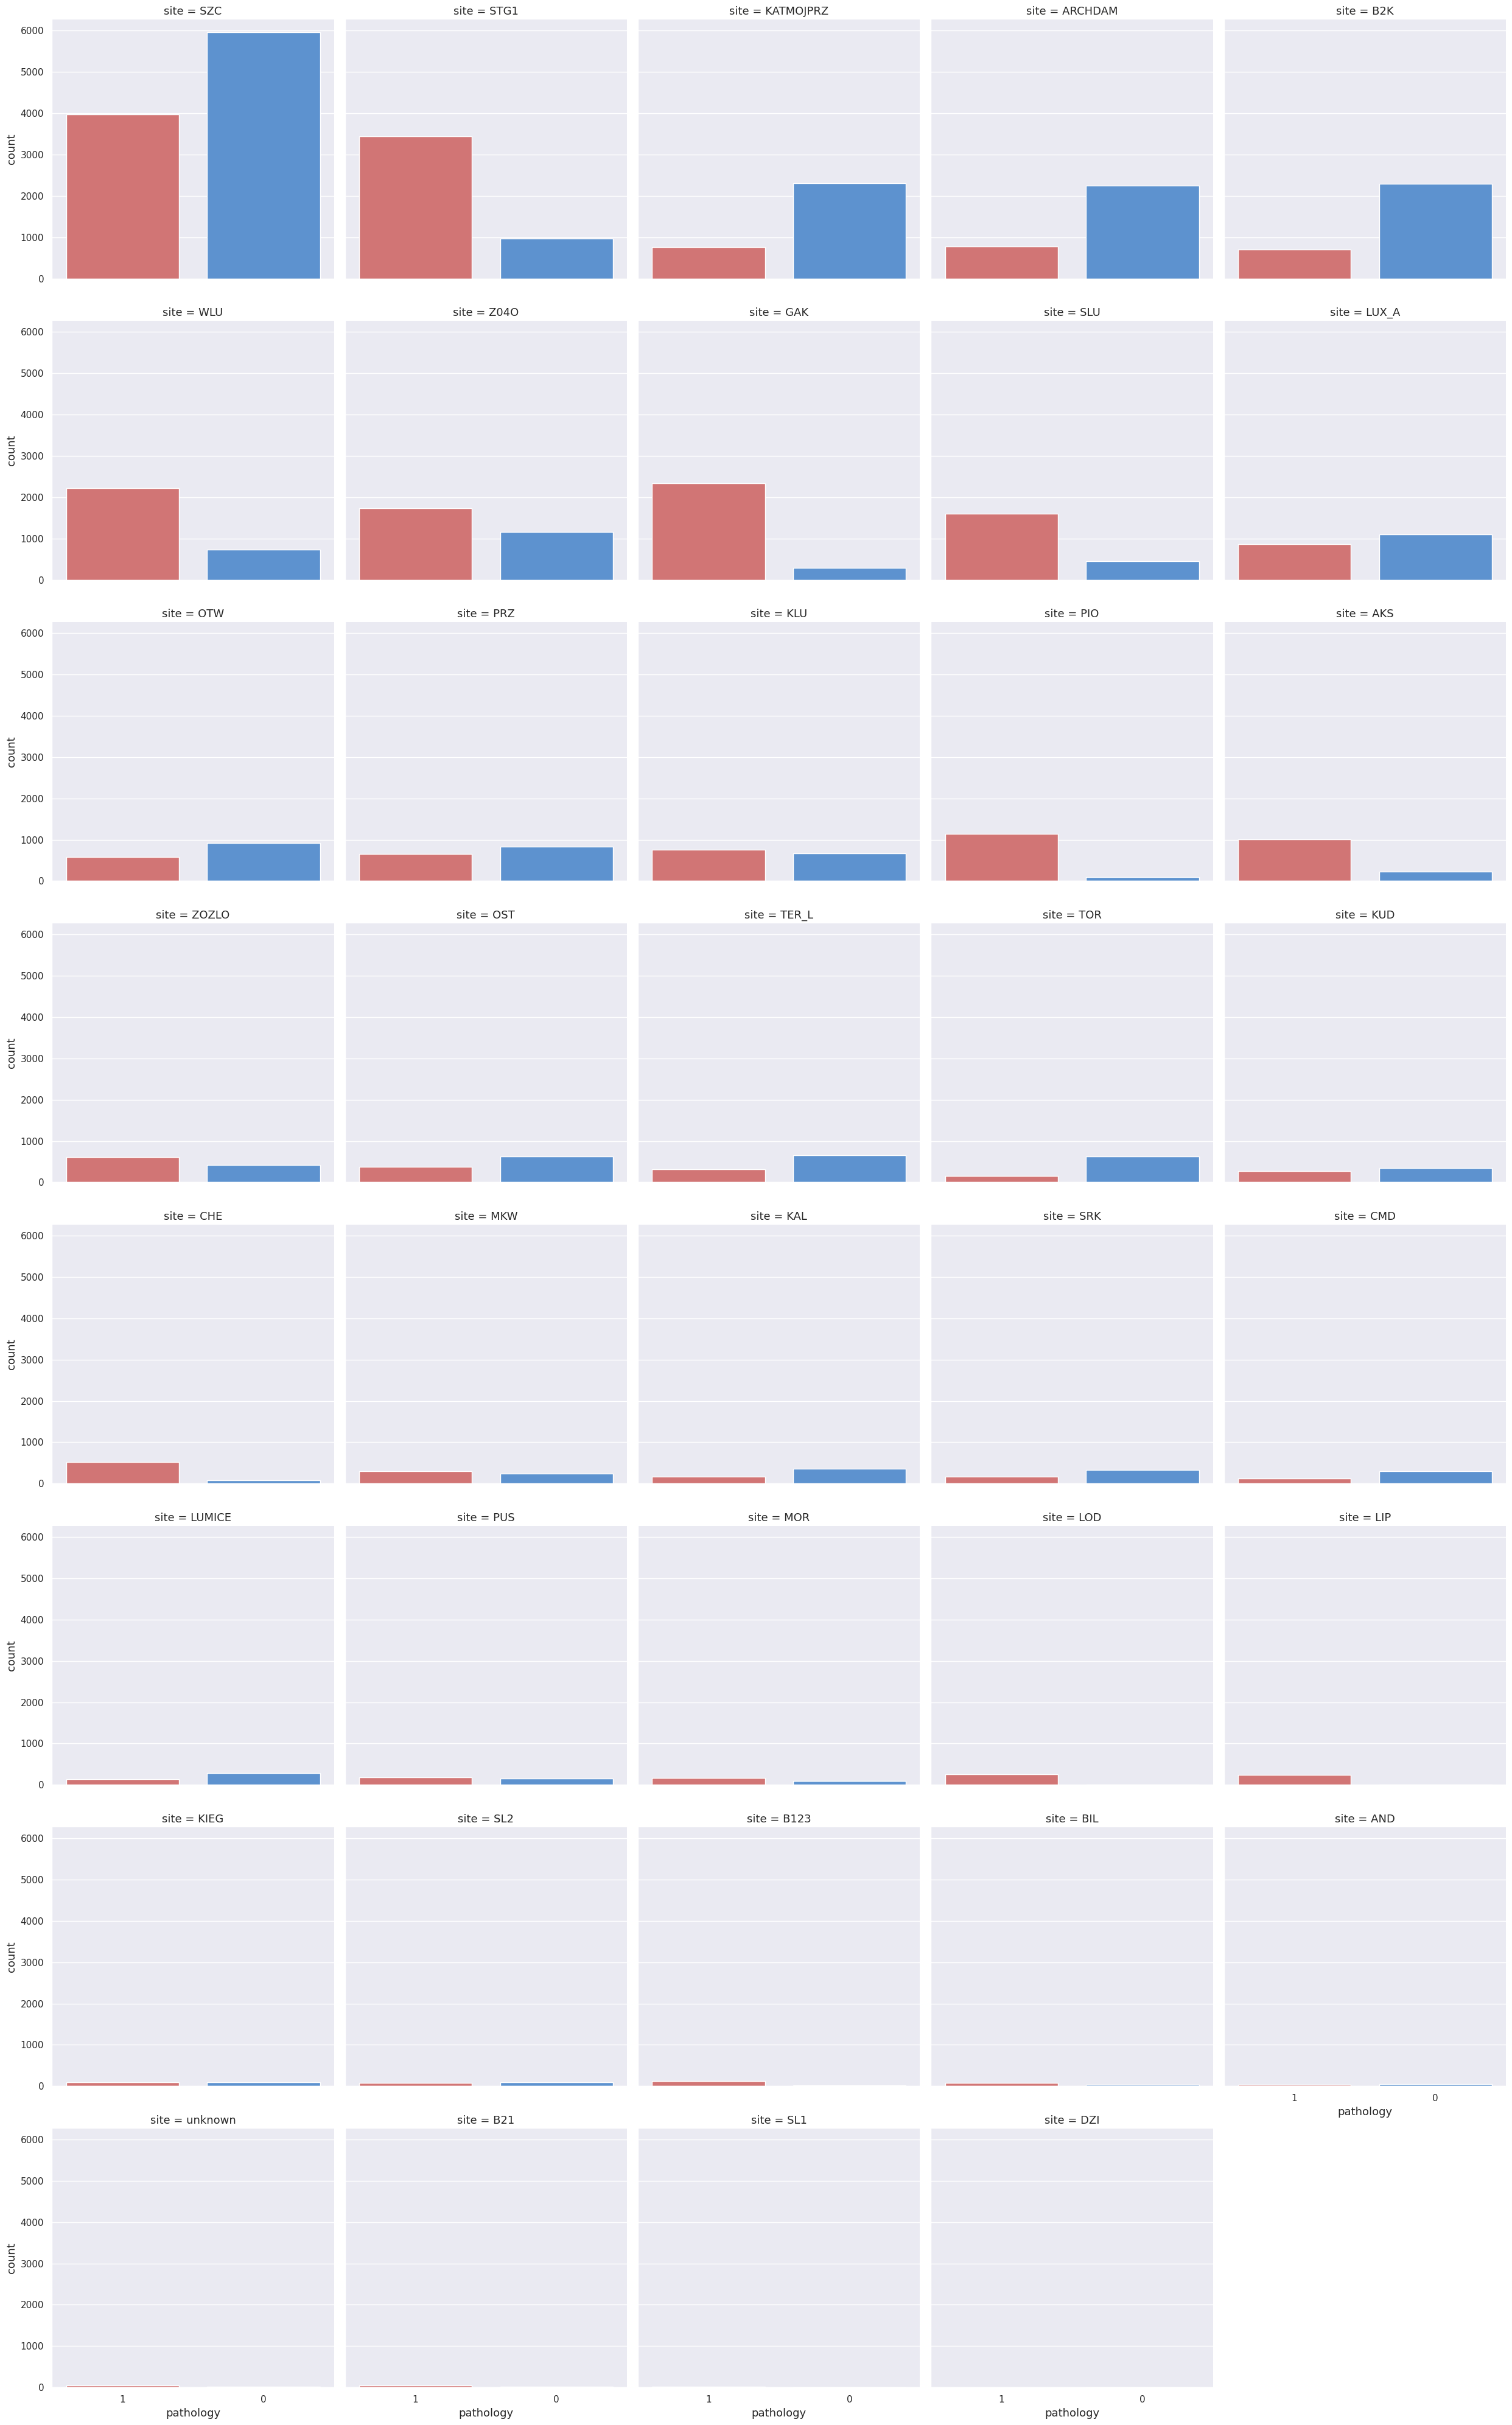

In [82]:
sns.catplot(x = 'pathology',
            data = data,
            col = 'site',
            col_wrap = 5,
            kind = 'count',
            order = [1,0],
            palette = LABEL_PALETTE,
            col_order = data['site'].value_counts().index)

Sites are diversed in observations volume and label distribution. It was assumed, that each group (target & control) has to have at least 50 recordings to proceed with this site. Otherwise, the site bias would overkill additional data advantade for trainig stage and deteriorate classifier generatization. 

In [83]:
mask = data[data['pathology'] == 0]['site'].value_counts()
N_control_min = 50

N_sites_too_small_CG = (mask < N_control_min).sum()
print(f"There are {N_sites_too_small_CG} hospitals to be excluded, because they have too small control group")
data = data[data['site'].isin(mask.index[mask>N_control_min])]
N_sites = len(set(data['site']))
print(f"After removal, {N_sites} sites remained in the dataset.")

There are 9 hospitals to be excluded, because they have too small control group
After removal, 30 sites remained in the dataset.


In [84]:
mask = data[data['pathology'] == 1]['site'].value_counts()
N_target_min = 50

N_sites_too_small_TG = (mask < N_target_min).sum()
print(f"There are {N_sites_too_small_TG} hospitals to be excluded (afetr prior CG criterion), because they have too small target group")
data = data[data['site'].isin(mask.index[mask>N_control_min])]
N_sites = len(set(data['site']))
print(f"After removal, {N_sites} sites remained in the dataset.")

There are 0 hospitals to be excluded (afetr prior CG criterion), because they have too small target group
After removal, 30 sites remained in the dataset.


# rename subs and sites after exclusions (leave exams for mapping with edfs)

In [85]:
patient_map = {uuid: f"P{i:05d}" for i, uuid in enumerate(data['patient_id'].unique(), start=0)} 
data['patient_id'] = data['patient_id'].map(patient_map) # unique and non-unique ids

In [86]:
site_mapping = {site: f"S{i:02d}" for i, site in enumerate(data['site'].value_counts().index, start=0)}
data['site'] = data['site'].map(site_mapping)
SITE_VOLUME_ORDER = data['site'].value_counts().index


In [87]:
site_mapping

{'SZC': 'S00',
 'STG1': 'S01',
 'KATMOJPRZ': 'S02',
 'ARCHDAM': 'S03',
 'B2K': 'S04',
 'WLU': 'S05',
 'Z04O': 'S06',
 'GAK': 'S07',
 'SLU': 'S08',
 'LUX_A': 'S09',
 'OTW': 'S10',
 'PRZ': 'S11',
 'KLU': 'S12',
 'PIO': 'S13',
 'AKS': 'S14',
 'ZOZLO': 'S15',
 'OST': 'S16',
 'TER_L': 'S17',
 'TOR': 'S18',
 'KUD': 'S19',
 'CHE': 'S20',
 'MKW': 'S21',
 'KAL': 'S22',
 'SRK': 'S23',
 'CMD': 'S24',
 'LUMICE': 'S25',
 'PUS': 'S26',
 'MOR': 'S27',
 'KIEG': 'S28',
 'SL2': 'S29'}

/tmp/ipykernel_1319104/853095513.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = 'pathology',


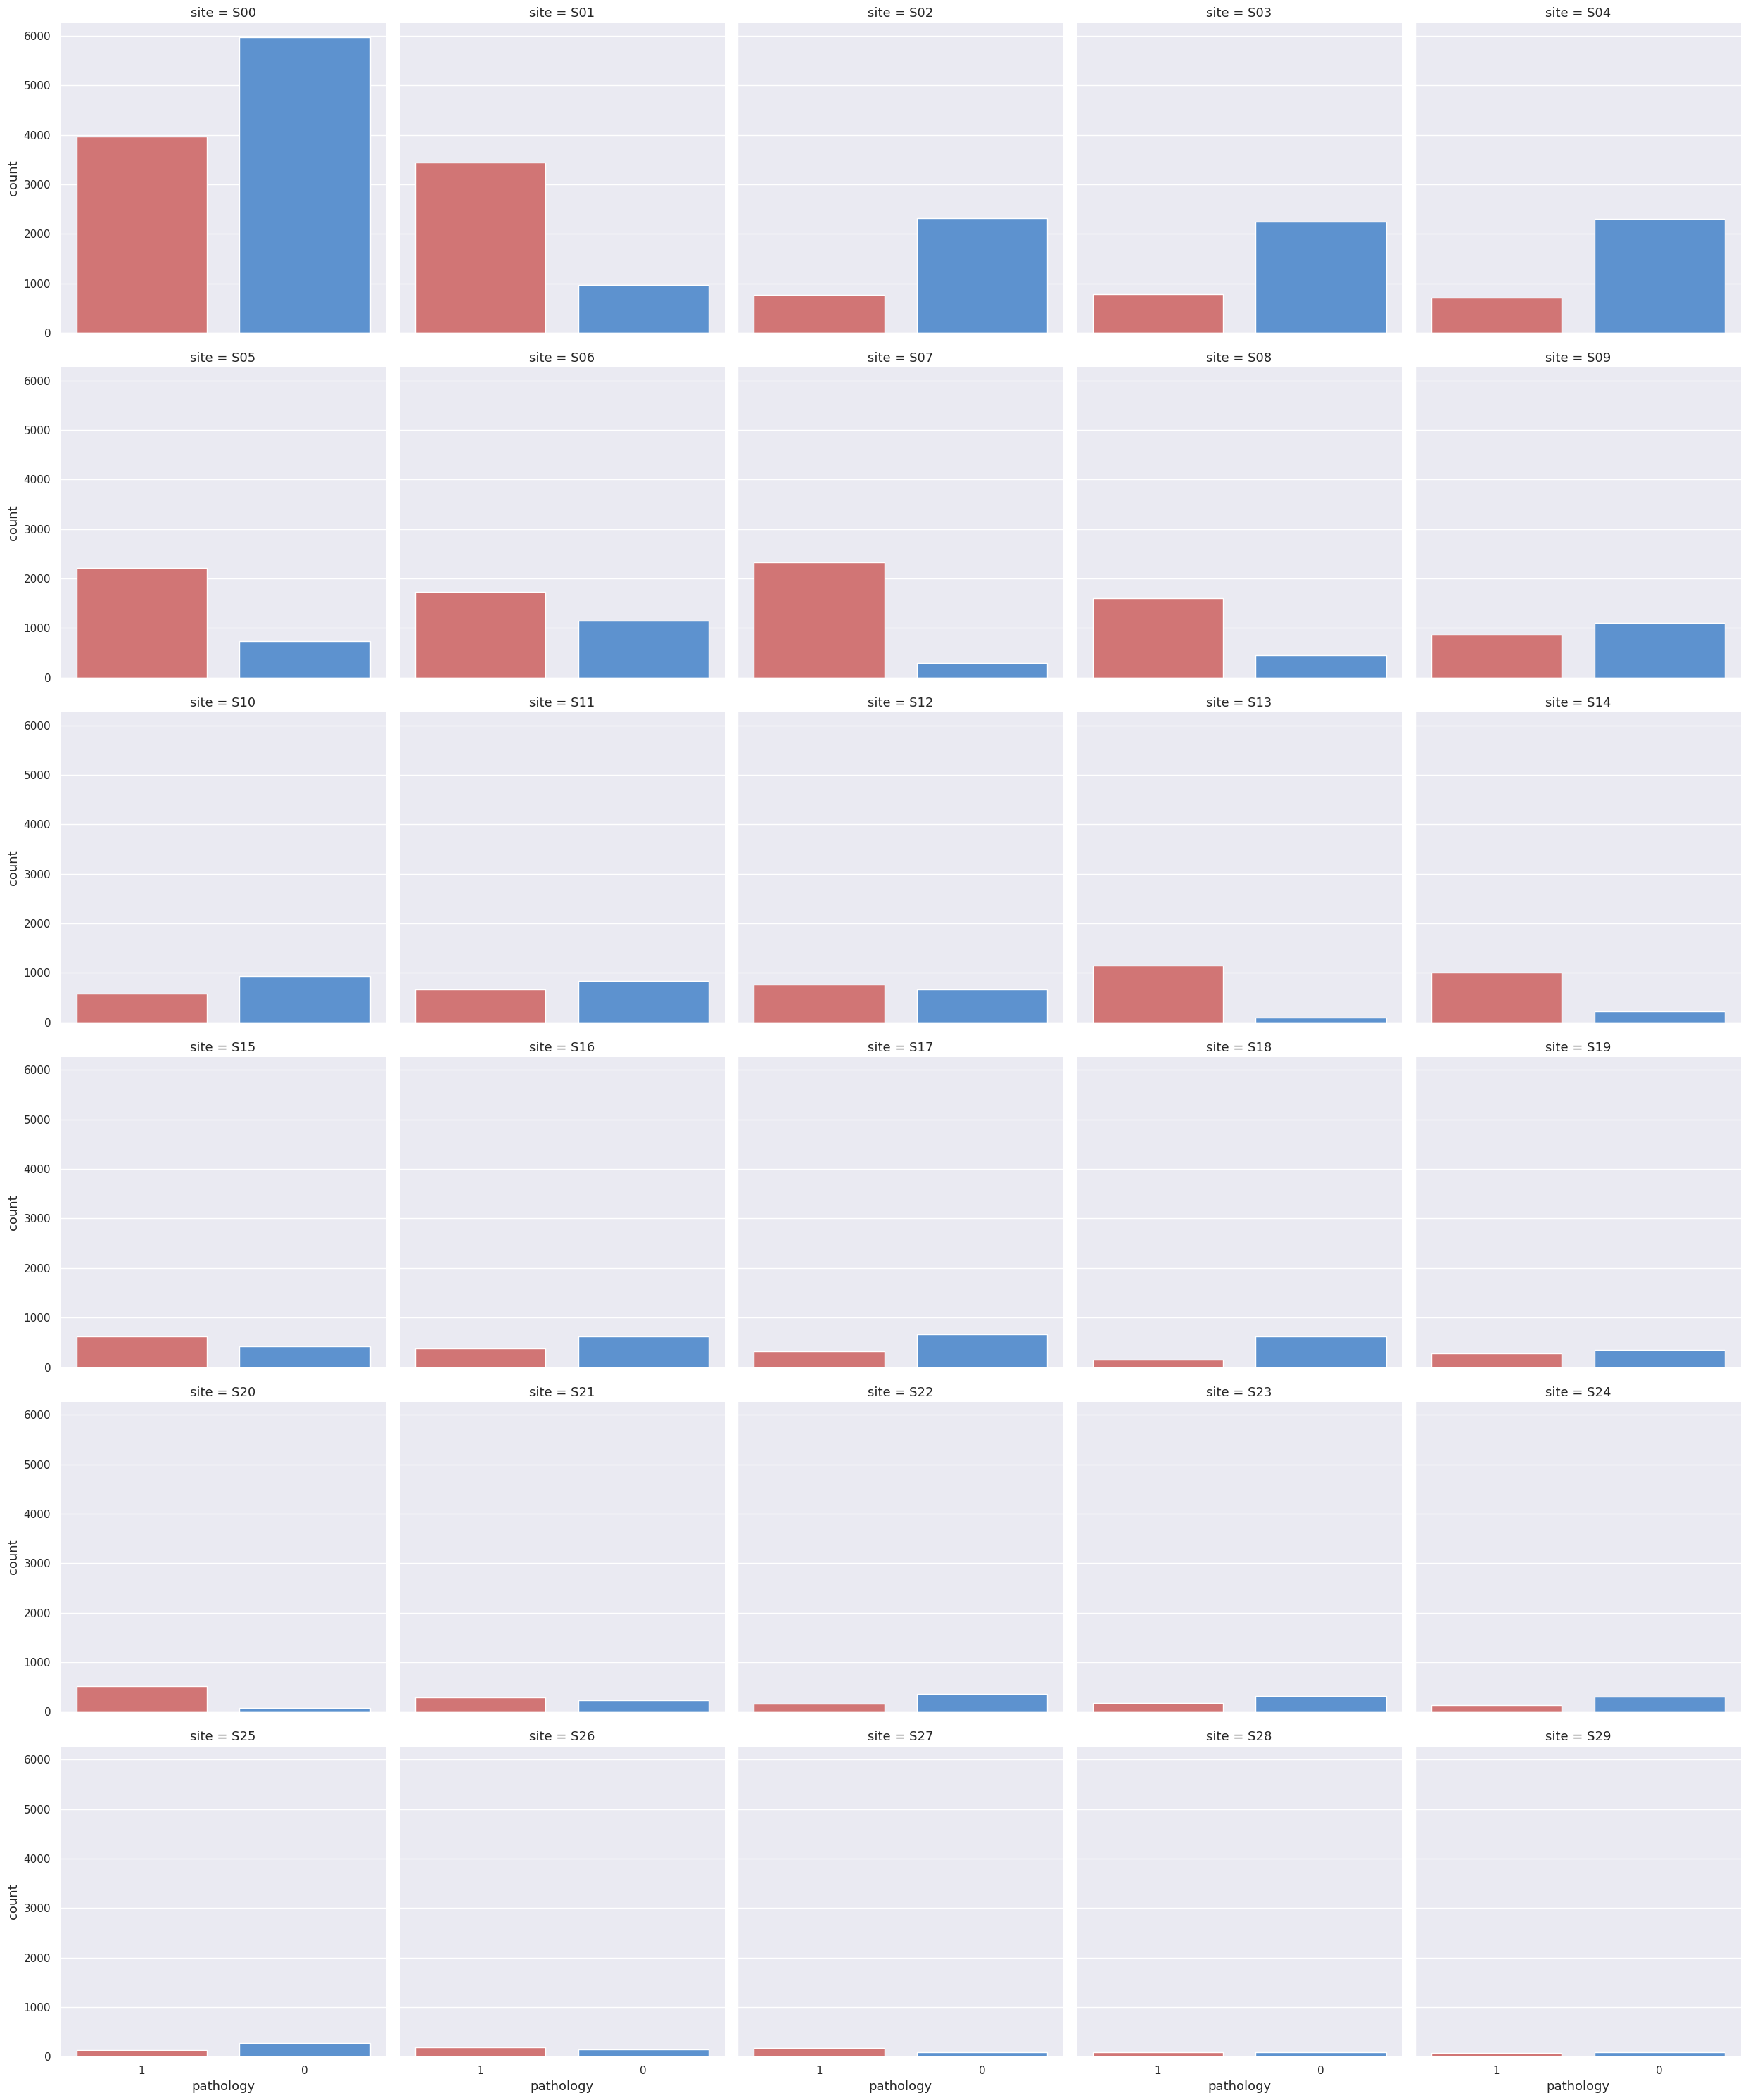

In [88]:
sns.catplot(x = 'pathology',
            data = data,
            col = 'site',
            col_wrap = 5,
            kind = 'count',
            order = [1,0],
            palette = LABEL_PALETTE,
            col_order = data['site'].value_counts().index)

In [89]:
data.isnull().any()

patient_id    False
exam_id       False
age           False
female        False
site          False
pathology     False
dtype: bool

There are no missing values.

In [90]:
data.head()

,patient_id,exam_id,age,female,site,pathology
0,P00000,20220411-162228-{4fe29d03-5025-46ca-8e14-c3b3f...,56.6,0,S17,0
1,P00001,20220510-150544-{cc1f09f8-3b30-40b4-91f8-4cd70...,38.0,0,S12,1
2,P00002,20220412-172841-{0881d6c7-8c23-4389-87c1-58c8e...,20.4,0,S01,1
3,P00003,20220530-182538-{85ec4ff0-fd03-4be2-a44b-99723...,23.6,1,S23,1
4,P00004,20220512-152511-{61074308-a109-40b1-97cb-43dcb...,60.6,0,S00,1


In [91]:
N_exams_final = data.shape[0]
excluded_ratio = ((N_exams_original - N_exams_final)/ N_exams_original) * 100

print(f"Finally, {excluded_ratio:.2f} % observations have been excluded due to old age, inconsistency or unrepresentativness of control group. \nThe dataset is now cleaned and renamed (without transforming examination_ids due to their role in mapping analyzed patients with their eegs).")

Finally, 8.34 % observations have been excluded due to old age, inconsistency or unrepresentativness of control group. 
The dataset is now cleaned and renamed (without transforming examination_ids due to their role in mapping analyzed patients with their eegs).


In [92]:
data.info() #metadata file itself is small ~2,7MB

<class 'pandas.core.frame.DataFrame'>
Index: 51135 entries, 0 to 55786
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient_id  51135 non-null  object 
 1   exam_id     51135 non-null  object 
 2   age         51135 non-null  float64
 3   female      51135 non-null  int64  
 4   site        51135 non-null  object 
 5   pathology   51135 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 2.7+ MB


# age binarization

For visualization purpose, it is good to binarize age to enable age-group analysis.

In [93]:
# binarize age into groups of 10 years, starting from 16 to 65
age_bins = list(range(16, 67, 10)) 
age_labels = [f'{i}-{i+9}' for i in range(16, 57, 10)] 
data['age_group'] = pd.cut(data['age'], bins=age_bins, labels=age_labels, right=False) # false means the right edge is not included in the bin

# by site
SITE_LABEL_ORDER = (data['pathology'] == 1).groupby(data['site']).mean().sort_values(ascending=False).index
age_distribution_per_site = pd.crosstab(data['site'], data['age_group'], normalize='index').mul(100).reindex(SITE_LABEL_ORDER)

In [94]:
AGE_GROUP_PALETTE = dict(zip(data['age_group'].cat.categories, sns.color_palette('hls', n_colors=data['age_group'].nunique() + 2)[2:]))

# descriptive statistics on preprocessed metadata

In [95]:
df_structure_global = pd.DataFrame({'Metric': [ '# exams', '# unique patients',
                                                '# longitudinal patients'],
                                    'Value': [  len(data), data['patient_id'].nunique(),
                                                data['patient_id'].value_counts().gt(1).sum()]})
df_structure_global.style.hide(axis='index')

Metric,Value
# exams,51135
# unique patients,41829
# longitudinal patients,4868


In [96]:
label_counts = data['pathology'].value_counts()
target_ratio = label_counts[1] / (label_counts[0] + label_counts[1])
relation = label_counts[1] / label_counts[0]

print("Target count: ", label_counts[1])
print("Target ratio (pathology/all labels):", target_ratio.round(2) * 100, '%') #type:ignore
print("Pathology : norm relation:", relation.round(2)) #type:ignore

Target count:  26218
Target ratio (pathology/all labels): 51.0 %
Pathology : norm relation: 1.05


In [97]:
sex_count = data['female'].value_counts()
female_ratio = sex_count[1] / (sex_count[0] + sex_count[1])
sex_relation = sex_count[1] / sex_count[0]

print("Female count: ", sex_count[1] )
print("Female ratio (female/all subjects):", female_ratio.round(2)*100, '%') #type:ignore   
print("Female : male relation:", sex_relation.round(1)) #type:ignore

Female count:  26890
Female ratio (female/all subjects): 53.0 %
Female : male relation: 1.1


In [98]:
age_group_counts = data['age_group'].value_counts().sort_index()

print('Sorted age group distribution :')
for age_group, count in age_group_counts.sort_values(ascending=False).items():
    print(f"Age group {age_group}: {count} ({(count / len(data) * 100):.2f}%)")  # type: ignore

Sorted age group distribution :
Age group 16-25: 13440 (26.28%)
Age group 26-35: 10617 (20.76%)
Age group 46-55: 9420 (18.42%)
Age group 36-45: 8989 (17.58%)
Age group 56-65: 8669 (16.95%)


In [99]:
data['age'].describe()

count    51135.000000
mean        38.566807
std         14.754388
min         16.000000
25%         25.200000
50%         37.400000
75%         52.000000
max         65.000000
Name: age, dtype: float64

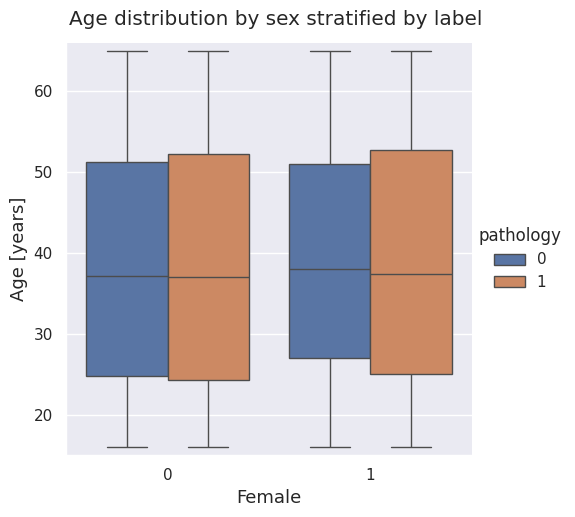

In [100]:
g = sns.catplot(
    x="female",
    y="age",
    data=data,
    hue="pathology",
    kind="box"
)

g.figure.suptitle(t = "Age distribution by sex stratified by label", y = 1.03)
g.set(
    xlabel="Female",
    ylabel="Age [years]",
    ylim=(15, 66)
)

/tmp/ipykernel_1319104/1322374756.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(x='age_group',


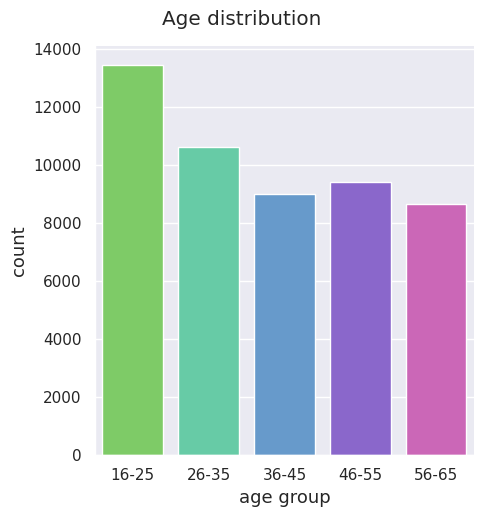

In [101]:
# age distribution (in bins of 10 years)
g = sns.catplot(x='age_group',
                data = data,
                kind = 'count',
                palette=AGE_GROUP_PALETTE)

g.figure.suptitle('Age distribution', y = 1.03)
g.set(xlabel = 'age group')


# interesting plots

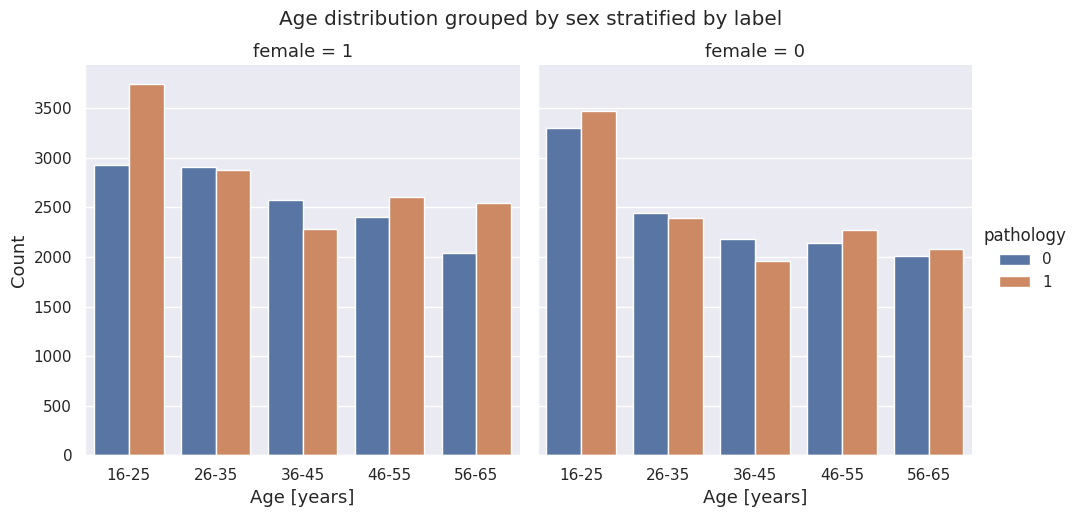

In [102]:
g = sns.catplot(x='age_group',
                data = data,
                hue = 'pathology',
                kind = 'count',
                col = "female",
                col_order= [1,0])

g.figure.suptitle('Age distribution grouped by sex stratified by label', y = 1.03)
g.set(xlabel = 'Age [years]', ylabel = 'Count')

/tmp/ipykernel_1319104/784255306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(x='pathology',


Text(0.5, 1.03, 'Label distribution per sex')

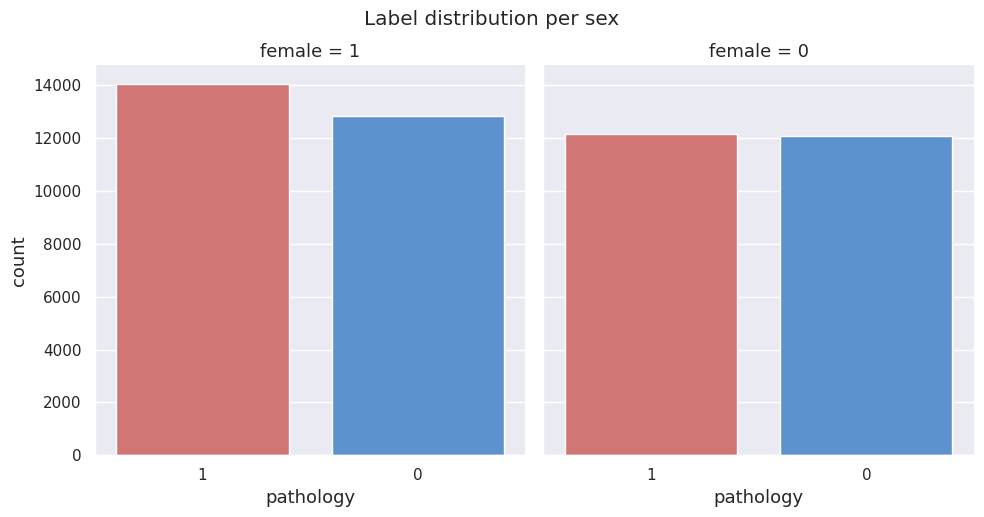

In [103]:
# label distribution x sex

g = sns.catplot(x='pathology', 
            data = data,
            kind = 'count',
            order = [1, 0],
            col = "female",
            col_order = [1,0],
            palette = LABEL_PALETTE)

g.figure.suptitle('Label distribution per sex', y = 1.03)


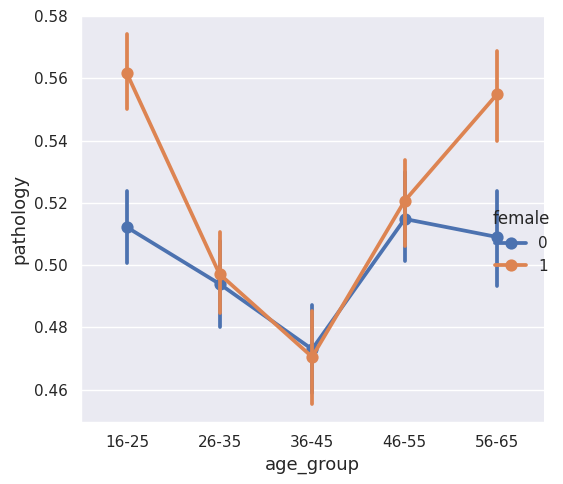

In [104]:
sns.catplot(x = "age_group",
            y = "pathology",
            data = data,
            kind = "point",
            hue = "female",
            legend_out=True)

plt.tight_layout()

### per site

In [105]:
SITE_VOLUME_ORDER

Index(['S00', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09',
       'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19',
       'S20', 'S21', 'S22', 'S23', 'S24', 'S25', 'S26', 'S27', 'S28', 'S29'],
      dtype='object', name='site')

In [106]:
sites_data = pd.DataFrame({
    'site': SITE_VOLUME_ORDER,
    '#exams': data['site'].value_counts().loc[SITE_VOLUME_ORDER].values,
    '#unique_subs': data.groupby('site')['patient_id'].nunique().loc[SITE_VOLUME_ORDER].values,
    '#unique_long_subs': data.groupby('site')['patient_id'].value_counts().gt(1).groupby('site').sum().loc[SITE_VOLUME_ORDER].values})

sites_data.style.hide(axis='index')

site,#exams,#unique_subs,#unique_long_subs
S00,9930,8184,948
S01,4401,3700,504
S02,3073,2470,354
S03,3017,1570,177
S04,3003,2062,410
S05,2957,2489,300
S06,2882,2204,416
S07,2622,2517,62
S08,2047,1497,325
S09,1972,1916,52


In [107]:
temp_df = pd.merge(data, sites_data, on=['site'], how='inner')
longitudinal_data = (
    temp_df
    .groupby(['site', 'patient_id'])
    .size()
    .loc[lambda x: x > 1]
    .reset_index(name='n_exams')
)

In [108]:
longitudinal_data

,site,patient_id,n_exams
0,S00,P00004,2
1,S00,P00005,2
2,S00,P00006,2
3,S00,P00009,17
4,S00,P00013,2
...,...,...,...
4863,S29,P22790,2
4864,S29,P29277,2
4865,S29,P29283,2
4866,S29,P29284,2


In [109]:
N_longs = len(longitudinal_data["site"].unique())

In [110]:
print("Number of sites with longitudinal patients:", N_longs)
print("The only site without longitudinal patients is:", set(data['site'].unique()) - set(longitudinal_data["site"].unique()))

Number of sites with longitudinal patients: 29
The only site without longitudinal patients is: {'S20'}


## exporting metadata tables

- `ELM19_metadata_exams.csv`: one row per examination (observation), after exclusions and with added age_group
- `ELM19_metadata_sites.csv`: one row per site (that had more that 50 observations of control and target), patient characetristics-specific (exams vs unique patients, longitudinal patients), sites are ordered by examination volume

The source metadata (linked on disk) file is not modified!! All the preprocessing happens locally in the project.

In [111]:
data = data[["site", "patient_id", "exam_id", "age", "age_group", "female", "pathology"]]

In [112]:
data = data.sort_values("site")

In [113]:
data.to_csv(new_filename_1, index=False)
sites_data.to_csv(new_filename_2, index=False)
longitudinal_data.to_csv(new_filename_3, index=False)

print(f"Saved examination metadata to: {new_filename_1}")
print(f"Saved site metadata to: {new_filename_2}")
print(f"Saved longitudinal patients metadata to: {new_filename_3}")

Saved examination metadata to: /dmj/fizmed/mmarzec/licencjat_neuro/DL-NS/data/meta/exams.csv
Saved site metadata to: /dmj/fizmed/mmarzec/licencjat_neuro/DL-NS/data/meta/sites.csv
Saved longitudinal patients metadata to: /dmj/fizmed/mmarzec/licencjat_neuro/DL-NS/data/meta/longitudinal.csv
